*© 2026 Zettnq · oi-volume-signal-research · MIT License*
### 07. S3 — Trigger Specification (1h directed confirmation)
Hypothesis: if an ‘trigger’ is required for entry, then a directed 1h confirmation (return and volume delta in the reverse direction) restores part of the oracle effect. The specification mirrors the logic of the live strategy.
Entry: end of episode → first directed 1-hour bar c (max_wait window) → open[c+1]. Entirely causal.
Expectation: ~50% WR, MFE/MAE ≈ 1 ⇒ by the time the 1-hour confirmation closes, the momentum has already passed.

In [1]:
from pathlib import Path

import oivdc_research  # installed via `pip install -e .`

# repo root: .../repo/src/oivdcr_research/__init__.py -> parents[2] = repo
PROJECT_ROOT = Path(oivdc_research.__file__).resolve().parents[2]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from oivdc_research.config import get_config

# Reproducibility parameters — edit here.
ASSET = "btcusdt"
TIMEFRAME = "1h"

CONFIG = get_config(
    project_root=PROJECT_ROOT,
    raw_csv_path=PROJECT_ROOT / "data" / "raw" / f"{ASSET}_{TIMEFRAME}.csv",
    timeframe=TIMEFRAME,
    asset=ASSET,
)

In [2]:
from oivdc_research.statistics import (
    compute_statistics_for_events_wide,
    format_stats_table,
    summarize_mfe_mae_symmetry,
)

events_s3 = pd.read_parquet(CONFIG.events_confirmation_path)

s3_stats = compute_statistics_for_events_wide(
    events_s3, CONFIG, method_name="confirmation", sample_type="nonoverlapping"
)
print(format_stats_table(s3_stats))

          method     sample_type signal_scope  horizon  n_events   winrate  \
0   confirmation  nonoverlapping     combined        1     12785  0.494408   
1   confirmation  nonoverlapping     combined        2     10634  0.492571   
2   confirmation  nonoverlapping     combined        3      8539  0.489987   
3   confirmation  nonoverlapping     combined        4      7134  0.501262   
4   confirmation  nonoverlapping     combined        5      6131  0.491437   
5   confirmation  nonoverlapping     combined       10      3635  0.493260   
6   confirmation  nonoverlapping         long        1      6267  0.501675   
7   confirmation  nonoverlapping         long        2      5206  0.504418   
8   confirmation  nonoverlapping         long        3      4209  0.498218   
9   confirmation  nonoverlapping         long        4      3542  0.513552   
10  confirmation  nonoverlapping         long        5      3043  0.501479   
11  confirmation  nonoverlapping         long       10      1766

In [3]:
# Comparison of S2 vs S3 (does the trigger add anything to the passive input?)
events_s2 = pd.read_parquet(CONFIG.events_episodes_path)
s2_stats = compute_statistics_for_events_wide(
    events_s2, CONFIG, method_name="episodes_feasible", sample_type="nonoverlapping"
)

contrast = pd.concat([
    s2_stats.assign(spec="S2_passive"),
    s3_stats.assign(spec="S3_trigger"),
])
print(
    contrast[contrast["signal_scope"] == "combined"]
    .pivot(index="horizon", columns="spec", values=["winrate", "mean_pnl", "t_stat"])
    .round(4)
)

           winrate              mean_pnl                t_stat           
spec    S2_passive S3_trigger S2_passive S3_trigger S2_passive S3_trigger
horizon                                                                  
1           0.5180     0.4944     0.0001    -0.0000     1.5316    -0.0336
2           0.5132     0.4926     0.0000    -0.0002     0.0341    -2.2744
3           0.5136     0.4900     0.0000    -0.0003     0.0437    -2.4393
4           0.5258     0.5013     0.0001    -0.0003     0.6633    -2.4137
5           0.5253     0.4914     0.0003    -0.0003     1.3428    -1.7753
10          0.5086     0.4933     0.0001    -0.0005     0.1744    -1.5547


Expected: S3 ≈ S2 ≈ 50% ⇒ a directional 1-hour confirmation does not restore the effect.

In [4]:
# MFE / MAE symmetry
sym = summarize_mfe_mae_symmetry(events_s3, CONFIG.horizons)
print(sym.round(4))

for h in (1, 2, 3):
    mfe = events_s3[f"mfe_{h}"].median()
    mae = events_s3[f"mae_{h}"].median()
    print(f"h={h}: median MFE={mfe:.5f}, median MAE={mae:.5f}, ratio={mfe / abs(mae):.3f}")

    horizon  threshold   p_mfe   p_mae   ratio
0         1     0.0005  0.8630  0.8680  0.9942
1         1     0.0010  0.7512  0.7499  1.0017
2         1     0.0020  0.5560  0.5491  1.0127
3         1     0.0030  0.4071  0.3943  1.0325
4         2     0.0005  0.9004  0.9088  0.9908
5         2     0.0010  0.8215  0.8250  0.9957
6         2     0.0020  0.6664  0.6669  0.9993
7         2     0.0030  0.5373  0.5331  1.0078
8         3     0.0005  0.9212  0.9277  0.9929
9         3     0.0010  0.8574  0.8600  0.9970
10        3     0.0020  0.7246  0.7279  0.9955
11        3     0.0030  0.6100  0.6078  1.0036
12        4     0.0005  0.9332  0.9388  0.9941
13        4     0.0010  0.8798  0.8808  0.9988
14        4     0.0020  0.7642  0.7638  1.0005
15        4     0.0030  0.6609  0.6582  1.0042
16        5     0.0005  0.9416  0.9459  0.9955
17        5     0.0010  0.8944  0.8950  0.9993
18        5     0.0020  0.7898  0.7919  0.9973
19        5     0.0030  0.6941  0.6940  1.0002
20       10  

Saved: reports/figures/s3/mfe_mae_symmetry.png


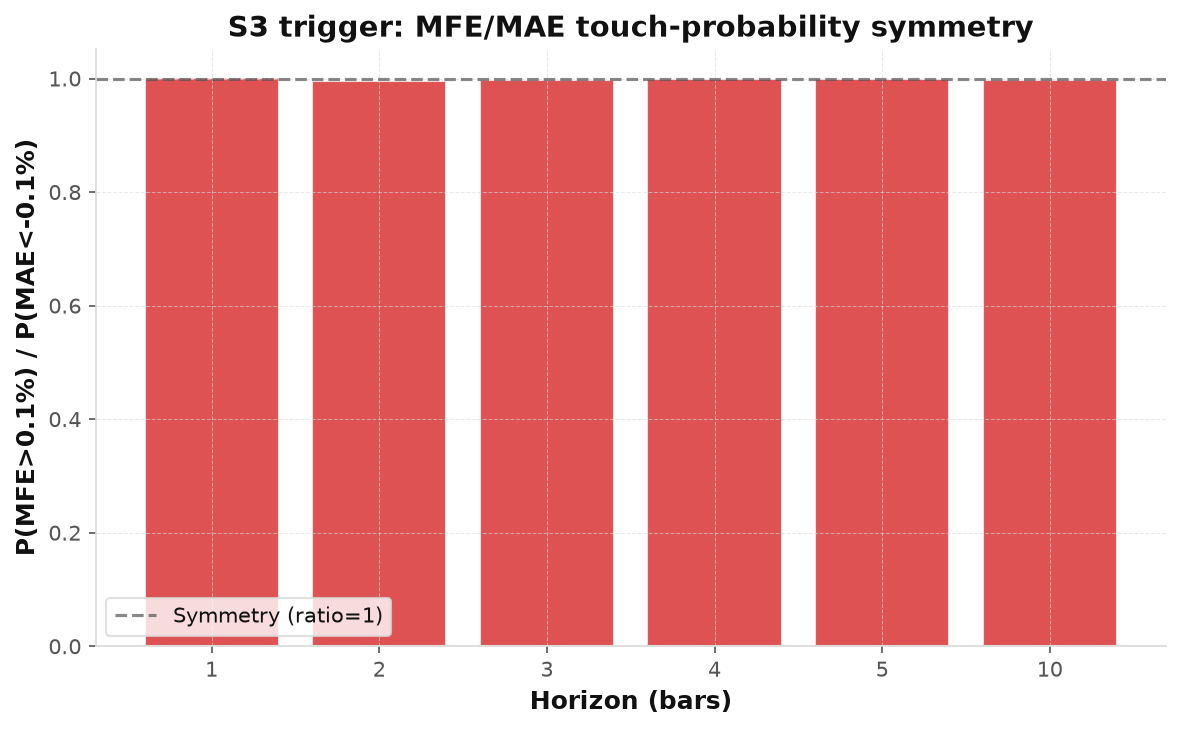

In [5]:
from oivdc_research.plotting import set_plot_style, get_palette, apply_axes_style, save_figure

set_plot_style(CONFIG.plot_theme)
pal = get_palette()

sym_main = sym[sym["threshold"] == 0.001]
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(sym_main["horizon"].astype(str), sym_main["ratio"],
       color=pal["short"], alpha=0.8, edgecolor=pal["background"])
ax.axhline(1.0, color=pal["text_secondary"], linestyle="--", linewidth=1.5,
           alpha=0.7, label="Symmetry (ratio=1)")
ax.set_xlabel("Horizon (bars)")
ax.set_ylabel("P(MFE>0.1%) / P(MAE<-0.1%)")
ax.set_title("S3 trigger: MFE/MAE touch-probability symmetry")
ax.legend()
apply_axes_style(ax)
plt.tight_layout()
save_figure(fig, CONFIG.figures_dir_for("s3") / "mfe_mae_symmetry.png")
plt.show()

Conclusions 07: S3 is flat and symmetrical ⇒ at 1h, the directional trigger does not generate a pulse; it remains within the gap bar ⇒ move on to 5m (08).